In [134]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [135]:
parent_dir = "/home/connorlab/Documents/GitHub/Julie/social_data/zombies_social_data/"
# Load data
aff_df = pd.read_excel(parent_dir + "zombies_feature_df_affiliation.xlsx", index_col=0)
sub_df = pd.read_excel(parent_dir + "zombies_feature_df_submission.xlsx", index_col=0)
ago_df = pd.read_excel(parent_dir + "zombies_feature_df_agonism.xlsx", index_col=0)

In [136]:
# 함수: "Behavior Towards 94B" → "94B"
def clean_col(colname):
    return colname.split()[-1]  # 마지막 단어만 추출

# 컬럼 이름 정리
aff_df.columns = [clean_col(c) for c in aff_df.columns]
sub_df.columns = [clean_col(c) for c in sub_df.columns]
ago_df.columns = [clean_col(c) for c in ago_df.columns]


# 공통 monkey 추출
monkeys = aff_df.index.intersection(sub_df.index).intersection(ago_df.index)

In [137]:
# Build behavior vector per monkey (row-wise vector from each matrix)
X = []
for m in monkeys:
    v = np.concatenate([
        aff_df.loc[m].values,
        sub_df.loc[m].values,
        ago_df.loc[m].values
    ])
    X.append(v)
X = np.array(X)
X

array([[ 0, 19,  9, 38, 84, 27, 13, 14,  4,  9,  0,  0,  0,  1,  0,  1,
         0,  0,  2,  0,  0,  4,  2,  7,  4,  7,  3,  9,  3,  2],
       [15,  0,  9, 41,  4, 13, 19, 71, 12,  0,  4,  0,  0, 13,  0,  0,
         0,  2,  1,  0,  0,  0,  0,  2,  1,  1,  8,  4,  2,  0],
       [18, 10,  0, 21,  7, 17, 49, 18,  3,  1,  9,  2,  0, 10,  0,  0,
         4,  3,  0,  0,  0,  1,  0,  0,  0,  7,  0,  1,  0,  2],
       [38, 43, 24,  0, 18,  6, 31, 26, 29,  4,  7,  0,  2,  0,  0,  0,
         0,  1,  6,  0,  1,  8,  0,  0,  9,  5,  6, 10, 11,  2],
       [90,  3,  8,  8,  0, 22,  8,  9,  1, 18, 11,  8,  3, 15,  0,  2,
         4,  2,  4, 18,  0,  0,  0,  0,  0,  1,  0,  1,  3, 10],
       [23, 12, 17,  1, 23,  0, 23, 16,  3, 10, 90, 16, 14, 43,  0,  0,
        10,  7,  9,  6,  0,  0,  0,  0,  2,  0,  0,  0,  3,  1],
       [17, 18, 43, 34, 10, 23,  0, 34,  2,  9, 29, 12,  1, 17,  0,  0,
         0, 23, 17,  1,  0,  0,  3,  2,  0,  4,  0,  1,  0,  6],
       [11, 70, 18, 17,  8, 17, 33,  0,  

In [138]:
# PCA
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X)

# Result as DataFrame
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=monkeys)

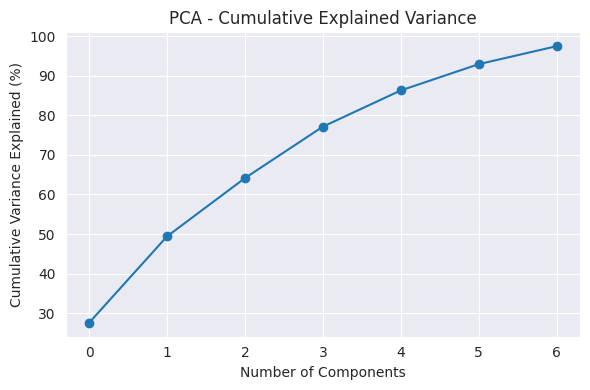

In [139]:
import matplotlib.pyplot as plt

# Cumulative explained variance plot
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_ * 100), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()


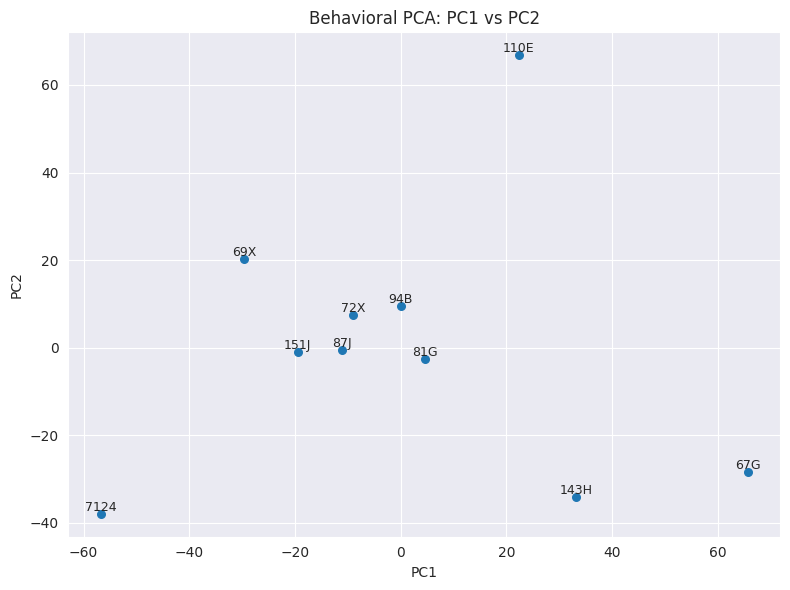

In [140]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=30)

# Add text labels
for i, label in enumerate(pca_df.index):
    plt.text(pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i], label,
             fontsize=9, ha='center', va='bottom')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Behavioral PCA: PC1 vs PC2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
from analyses.spike_rate import compute_mean_spike_rate_for_windows
from analyses.enums.monkey_names import get_monkeys_by_default_order
import pandas as pd
monkey_group = "Zombies"
subject_monkey_index = 6
monkey_list = get_monkeys_by_default_order(monkey_group)
sig_windows = pd.read_pickle(
        f'/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_cache/{monkey_group}_significant_windows_pANOVAorGLM_passed.pkl')
mean_spike_rate_windows = compute_mean_spike_rate_for_windows(sig_windows)

Computing windowed mean spike rate: 100%|██████████| 525/525 [00:08<00:00, 64.60it/s]


In [77]:
# 1. Remove 81G from PCA DataFrame
pca_df_clean = pca_df.drop(index="81G")

# 2. monkey_list와 순서 맞추기
pca_df_clean = pca_df_clean.loc[[m for m in monkey_list if m != "81G"]]
print(pca_df_clean)
# 3. PCA matrix 만들기
pca_matrix = pca_df_clean.to_numpy()  # shape: (n_monkeys - 1, n_components)

                  PC1        PC2        PC3        PC4        PC5        PC6  \
Focal Name                                                                     
7124       -56.737005 -37.898924 -21.034035 -17.411564 -26.000133  -4.919399   
69X        -29.558194  20.314815  48.292973  16.370872  -1.764805 -14.996222   
72X         -9.006608   7.474192  -0.569052  12.323962  22.587549 -15.802019   
94B          0.005764   9.629948 -23.594407  35.569263 -10.354981 -12.004770   
110E        22.345207  66.771045 -24.427713 -15.890878 -14.236428   5.293407   
67G         65.658189 -28.255519  14.860434 -27.821453  -5.918120 -21.351737   
143H        33.212884 -34.077294 -16.747618  34.629013   7.561238  15.333766   
87J        -11.091851  -0.551781   8.161914 -14.301184  29.909137  19.483891   
151J       -19.455993  -0.917706 -15.623747 -24.433286  21.935172   0.340002   

                  PC7  
Focal Name             
7124       -10.897822  
69X         -1.803295  
72X        -18.456183  

In [78]:
subset_spike_rate_df = mean_spike_rate_windows[
    (mean_spike_rate_windows['MonkeyGroup'] == 'Zombies')]

In [79]:
def run_simple_pca_regression(spike_df, pca_df, n_components=3):
    import statsmodels.api as sm
    from tqdm import tqdm

    results = []

    grouped = spike_df.groupby(['NeuronID', 'WindowStart_ms', 'WindowEnd_ms'])

    for (neuron_id, w_start, w_end), group in tqdm(grouped, desc='Running PCA regressions'):
        group = group.set_index('MonkeyName')
        monkeys_in_window = group.index.intersection(pca_df.index)

        if len(monkeys_in_window) < n_components + 2:
            continue  # not enough data

        y = group.loc[monkeys_in_window, 'MeanSpikeRate'].values
        X = pca_df.loc[monkeys_in_window, [f'PC{i+1}' for i in range(n_components)]].values
        X = sm.add_constant(X)

        try:
            model = sm.OLS(y, X).fit()
            results.append({
                'NeuronID': neuron_id,
                'WindowStart_ms': w_start,
                'WindowEnd_ms': w_end,
                'R_squared': model.rsquared,
                'p_values': model.pvalues.tolist(),
                'coefficients': model.params.tolist()
            })
        except Exception as e:
            print(f"{neuron_id} ({w_start}-{w_end}) failed: {e}")
            continue

    return pd.DataFrame(results)


results_df = run_simple_pca_regression(subset_spike_rate_df, pca_df, n_components=4)


Running PCA regressions: 100%|██████████| 525/525 [00:00<00:00, 907.90it/s]


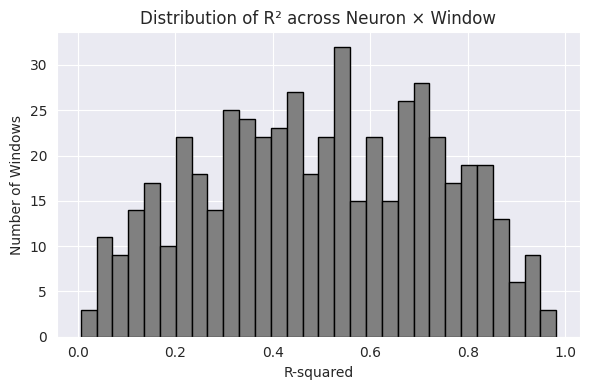

In [80]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(6, 4))
plt.hist(results_df['R_squared'], bins=30, color='gray', edgecolor='black')
plt.xlabel('R-squared')
plt.ylabel('Number of Windows')
plt.title('Distribution of R² across Neuron × Window')
plt.grid(True)
plt.tight_layout()
plt.show()


In [81]:
threshold = 0.6
n_sig = (results_df['R_squared'] > threshold).sum()
n_total = len(results_df)

print(f"{n_sig} out of {n_total} windows had R² > {threshold:.2f} ({n_sig/n_total:.1%})")


190 out of 525 windows had R² > 0.60 (36.2%)


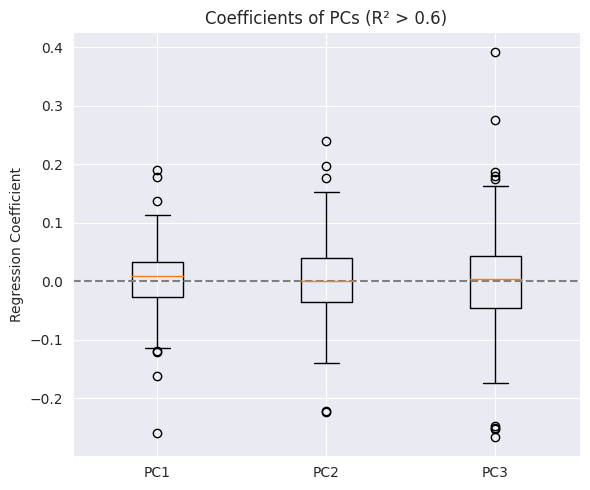

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# 필터링
high_r2_df = results_df[results_df['R_squared'] > 0.6]

# 각 PCA component의 계수만 분리 (intercept 제외)
coefs = np.array(high_r2_df['coefficients'].tolist())[:, 1:]  # shape: (N, 3)

# Boxplot or scatter
plt.figure(figsize=(6, 5))
plt.boxplot([coefs[:, 0], coefs[:, 1], coefs[:, 2]], labels=['PC1', 'PC2', 'PC3'])
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('Regression Coefficient')
plt.title('Coefficients of PCs (R² > 0.6)')
plt.tight_layout()
plt.show()


In [83]:
coeffs = results_df['coefficients'].apply(lambda x: x[1:])  # Drop intercept
coeff_matrix = np.stack(coeffs.to_numpy())  # shape: (n_neurons, n_PCs)


In [84]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Optional: normalize each neuron’s coefficient vector
coeff_scaled = StandardScaler().fit_transform(coeff_matrix)

# Try 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(coeff_scaled)

# Attach labels back to results_df
results_df['Cluster'] = labels

/home/connorlab/Documents/GitHub/Julie/venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



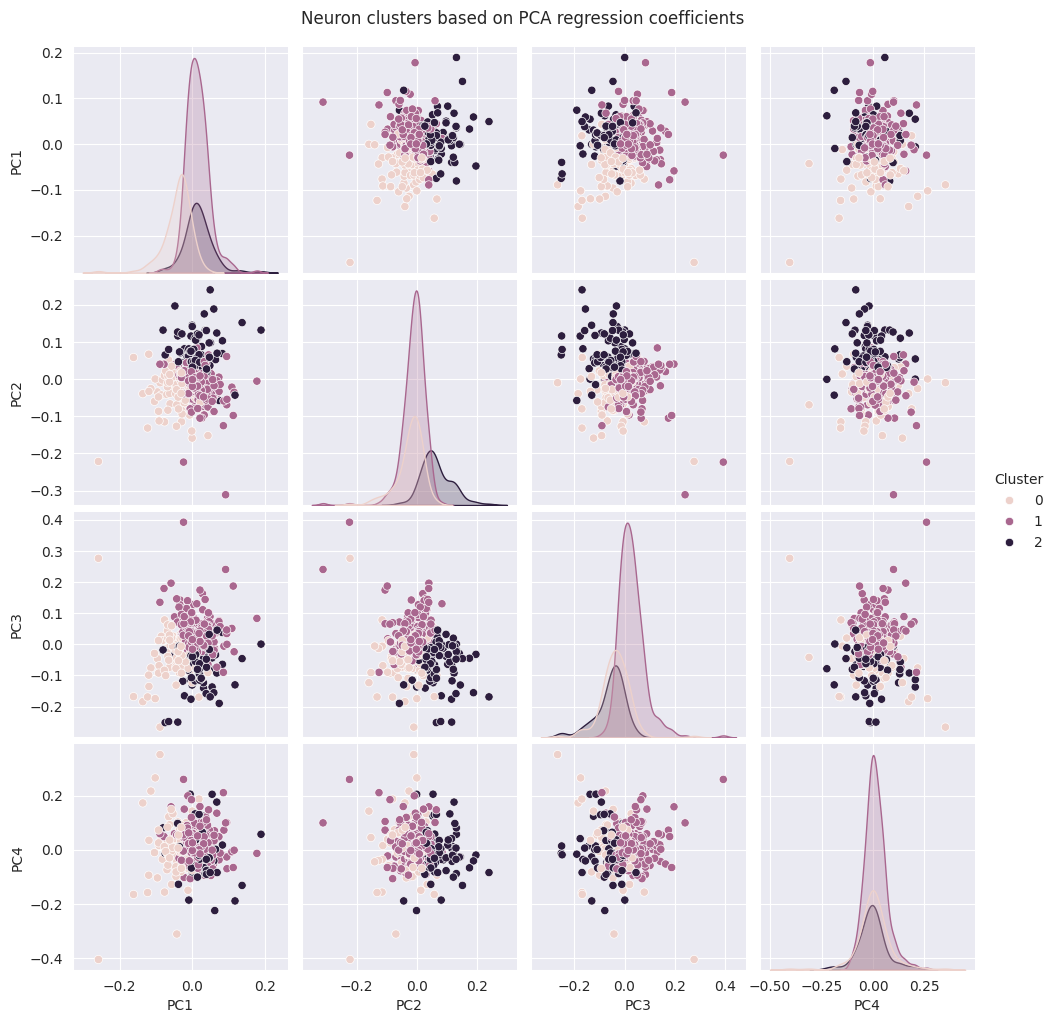

In [85]:
import seaborn as sns
import pandas as pd

plot_df = pd.DataFrame(coeff_matrix, columns=['PC1', 'PC2', 'PC3', 'PC4'])
plot_df['Cluster'] = labels

sns.pairplot(plot_df, hue='Cluster', diag_kind='kde')
plt.suptitle('Neuron clusters based on PCA regression coefficients', y=1.02)
plt.show()


In [101]:
aff_cols = aff_df.columns
sub_cols = sub_df.columns
ago_cols = ago_df.columns
# Prefix to indicate behavior type
aff_features = [f'Aff_{c}' for c in aff_cols]
sub_features = [f'Sub_{c}' for c in sub_cols]
ago_features = [f'Ago_{c}' for c in ago_cols]

# Combine into full feature list (matches column order of X)
feature_names = aff_features + sub_features + ago_features

# Loadings matrix: shape (n_features, n_components)
loadings = pca.components_.T  # transpose so rows = original features

# Turn into DataFrame
loadings_df = pd.DataFrame(
    loadings,
    index=feature_names,  # your original behavioral variables
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print(loadings_df)


                   PC1       PC2       PC3       PC4       PC5       PC6  \
Aff_7124  2.988633e-01  0.681299 -0.317206 -0.018357 -0.420890 -0.103011   
Aff_69X   1.912071e-01 -0.332843 -0.331932  0.657040 -0.154492  0.272338   
Aff_72X   1.197786e-01 -0.070751  0.138471  0.169809 -0.418468  0.311113   
Aff_94B  -2.784053e-01 -0.074360  0.349198  0.053258 -0.123129  0.283319   
Aff_110E -3.442894e-01 -0.456958 -0.330469 -0.336428 -0.538864 -0.325774   
Aff_67G  -1.011590e-01  0.029702 -0.057135  0.043290 -0.262880  0.151984   
Aff_81G   9.269294e-02 -0.081342 -0.094410  0.416532  0.146600 -0.546047   
Aff_143H -1.611425e-01  0.161201  0.631625  0.284711 -0.351202 -0.379814   
Aff_87J  -3.299175e-02  0.023043 -0.053180  0.219276 -0.069634 -0.202128   
Aff_151J  5.472426e-02  0.058724 -0.048577 -0.116117 -0.138786  0.098647   
Sub_7124  6.727488e-01 -0.365331  0.231610 -0.240296 -0.088173 -0.147128   
Sub_69X   1.324181e-01 -0.016650  0.051740 -0.080882 -0.084702  0.056324   
Sub_72X   9.

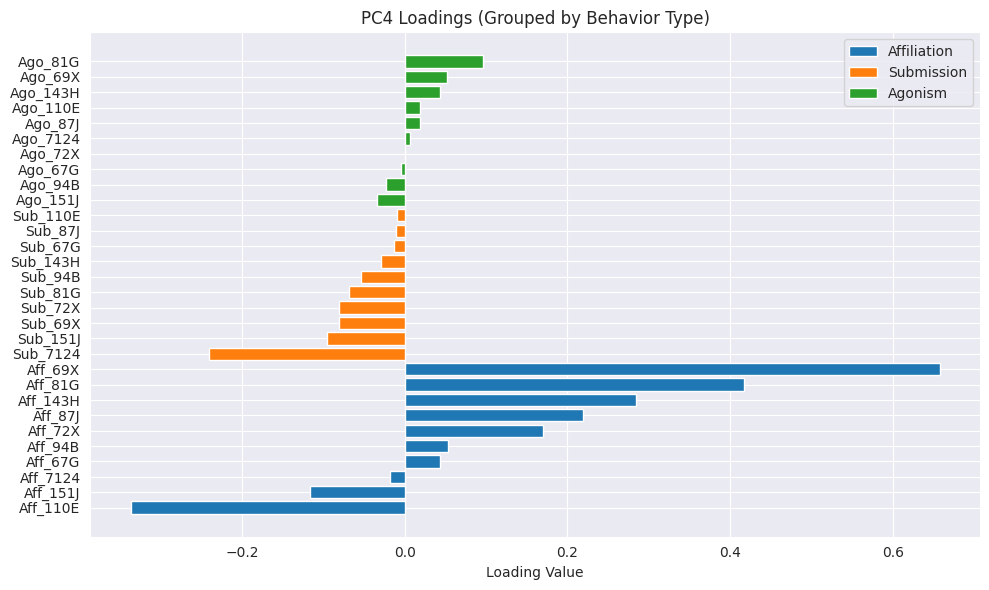

In [107]:
import matplotlib.pyplot as plt

# Prepare
pc_to_plot = 'PC4'
loadings_pc = loadings_df[pc_to_plot]
group_labels = ['Affiliation'] * len(aff_cols) + ['Submission'] * len(sub_cols) + ['Agonism'] * len(ago_cols)

# Make a DataFrame with grouping
plot_df = pd.DataFrame({
    'Feature': feature_names,
    'Loading': loadings_pc,
    'Group': group_labels
}).sort_values('Loading')
group_list = plot_df['Group'].unique()
# Plot
plt.figure(figsize=(10, 6))
for g in group_list:
    subset = plot_df[plot_df['Group'] == g]
    plt.barh(subset['Feature'], subset['Loading'], label=g)

plt.title(f"{pc_to_plot} Loadings (Grouped by Behavior Type)")
plt.xlabel("Loading Value")
plt.legend()
plt.tight_layout()
plt.show()


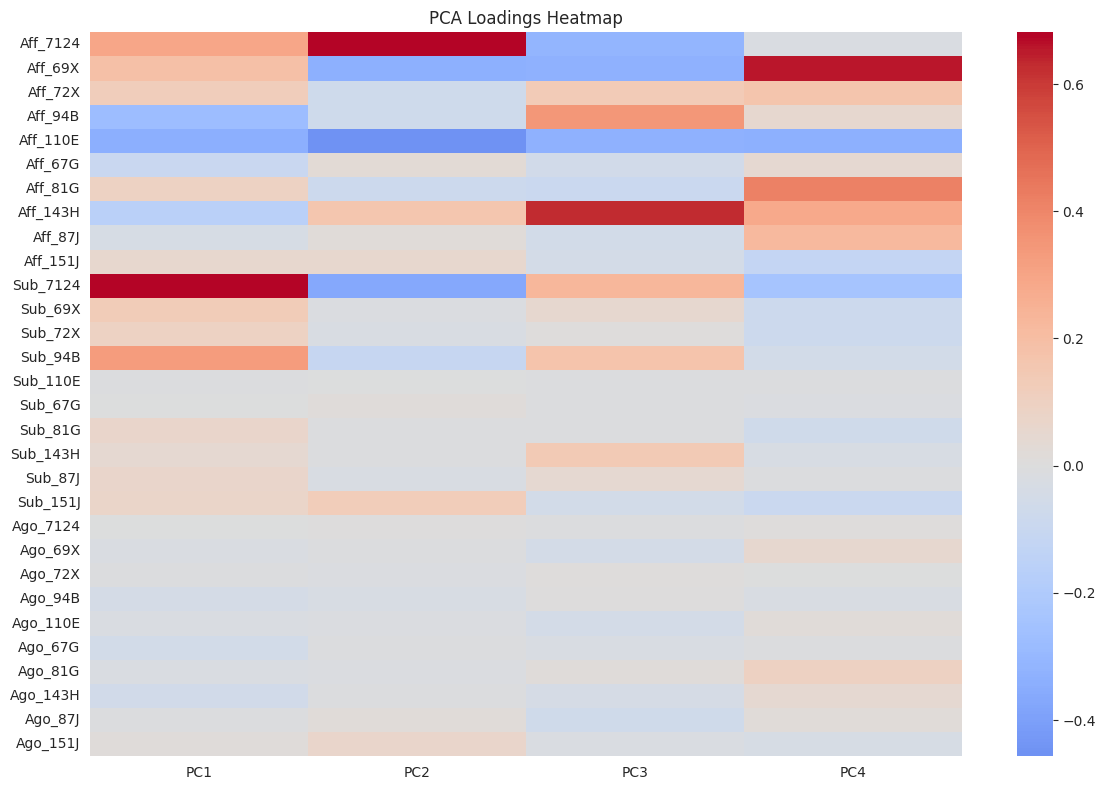

In [108]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    loadings_df.loc[feature_names, ['PC1', 'PC2', 'PC3', 'PC4']],
    cmap='coolwarm', center=0,
    yticklabels=True
)
plt.title("PCA Loadings Heatmap")
plt.tight_layout()
plt.show()


In [123]:
## RSA
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# 1. Get mean spike rate per monkey (across all neurons and windows)
pivoted = subset_spike_rate_df.pivot_table(
    index='MonkeyName',
    columns='NeuronID',
    values='MeanSpikeRate',
    aggfunc='mean'
)
print(pivoted)
# Align monkeys
common_monkeys = pivoted.index.intersection(pca_df_clean.index)
neural_mat = pivoted.loc[common_monkeys].values
pca_mat = pca_df_clean.loc[common_monkeys].values
print(pca_mat.shape)

# 2. Compute dissimilarity matrices (Euclidean or correlation distance)
neural_rdm = squareform(pdist(neural_mat, metric='correlation'))
behavior_rdm = squareform(pdist(pca_mat, metric='correlation'))

# 3. Compute correlation between RDMs
rsa_corr, rsa_p = spearmanr(neural_rdm.flatten(), behavior_rdm.flatten())
# rsa_corr, rsa_p = pearsonr(neural_rdm.flatten(), behavior_rdm.flatten())

print(f"RSA Spearman r = {rsa_corr:.3f}, p = {rsa_p:.4f}")


NeuronID    AMG_2023-09-26_1_Channel.C_014_Unit 1  \
MonkeyName                                          
110E                                    56.507937   
143H                                    64.571429   
151J                                    66.349206   
67G                                     60.000000   
69X                                     66.349206   
7124                                    72.000000   
72X                                     50.000000   
87J                                     59.428571   
94B                                     42.448980   
NewMonkey                                     NaN   

NeuronID    AMG_2023-09-26_1_Channel.C_018_Unit 1  \
MonkeyName                                          
110E                                     2.222222   
143H                                     2.000000   
151J                                     2.777778   
67G                                      1.000000   
69X                                      3.88

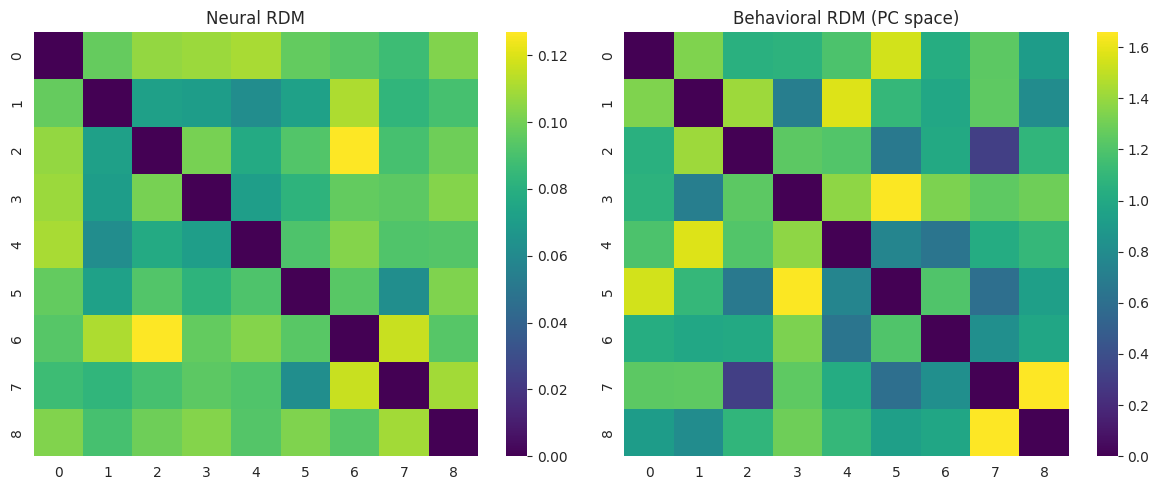

In [114]:
# Plot the two RDMs side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(neural_rdm, ax=axs[0], cmap='viridis')
axs[0].set_title('Neural RDM')

sns.heatmap(behavior_rdm, ax=axs[1], cmap='viridis')
axs[1].set_title('Behavioral RDM (PC space)')

plt.tight_layout()
plt.show()

In [133]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Use same monkey alignment as RSA
X = neural_mat  # neural responses
Y = pca_mat[:, :7]  # PC1–3

pls = PLSRegression(n_components=3)
cv = KFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(pls, X, Y, cv=cv, scoring='r2')

print(f"Mean PLS R²: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

Mean PLS R²: -5.355 ± 2.542
